# Physics-Based Unsupervised / Self-Supervised Deep Learning for Adaptive Multiple Attenuation

This notebook demonstrates a **patch-based, unsupervised/self-supervised workflow** for adaptive multiple attenuation on the SWAN synthetic prestack dataset.

We use **one sample only**, without accessing the ground-truth label during training:

- `data[0, 0, :, :]` → observed prestack data
- `data[1, 0, :, :]` → predicted multiple model

The idea is to mimic **adaptive matching filtering** with a neural network, but in a modern deep learning form.

## Core idea

Let

- \(d\) = observed data
- \(m\) = predicted multiple model
- \(P\) = patching operator
- \(P^{-1}\) = inverse patching operator
- \(f_\theta\) = neural network (U-Net)

We first patch both observed data and the predicted multiple:

$
X_d = P(d), \qquad X_m = P(m)
$

Then we train a neural network to produce an **adaptively matched multiple estimate** from the input multiple patches:

$
X_{m,\mathrm{out}} = f_\theta(X_m)
$

and define the corresponding primary patches as:

$
X_{p,\mathrm{out}} = X_d - f_\theta(X_m)
$

Finally, the patch-domain outputs are reconstructed back to the original image domain:

$
m_{\mathrm{out}} = P^{-1}(X_{m,\mathrm{out}}), \qquad
p_{\mathrm{out}} = P^{-1}(X_{p,\mathrm{out}})
$

So the final estimated primary is

$
p_{\mathrm{out}} = d - P^{-1} f_\theta(P(m))
$

## Why this is physics-based / self-supervised

This workflow is **unsupervised/self-supervised** because:

- no ground-truth primary is used in training
- the observed data itself provides the fitting target
- the predicted multiple model acts as the physical prior
- the subtraction structure enforces a physically meaningful decomposition:
  observed data = primary + matched multiple

## 1. Install dependencies

In [ ]:
# Uncomment and run if needed
# !pip install pyseistr
# !pip install torch matplotlib numpy

## 2. Imports and reproducibility

In [1]:
import os
import math
import random
from typing import Dict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from pyseistr import patch2d, patch2d_inv

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## 3. Configuration

In [16]:
npz_path = "../dataset/SWAN_syn_prestack_multiple.npz"
output_dir = "./outputs_swan_unsupervised_patch_unet"
os.makedirs(output_dir, exist_ok=True)

sample_idx = 10

# Patching parameters
l1 = 32
l2 = 32
s1 = 4
s2 = 4

# Training parameters
batch_size = 64
num_epochs = 80
learning_rate = 1e-3
weight_decay = 1e-6

# Loss weights
lambda_recon = 1.0
lambda_smooth = 1e-4
lambda_primary = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 4. Load one SWAN sample

In [17]:
pack = np.load(npz_path)

data = pack["data"]
label = pack["label"]

print("data shape :", data.shape)
print("label shape:", label.shape)

obs = data[0, sample_idx].astype(np.float32)
multiple = data[1, sample_idx].astype(np.float32)
gt_primary = label[0, sample_idx].astype(np.float32) if "label" in pack else None

n1, n2 = obs.shape
print("Single observed sample shape :", obs.shape)
print("Single multiple sample shape :", multiple.shape)

data shape : (2, 512, 256, 256)
label shape: (1, 512, 256, 256)
Single observed sample shape : (256, 256)
Single multiple sample shape : (256, 256)


## 5. Normalize by the observed-data amplitude scale

In [18]:
eps = 1e-8
scale = max(np.max(np.abs(obs)), eps)

obs_norm = obs / scale
multiple_norm = multiple / scale
gt_primary_norm = gt_primary / scale if gt_primary is not None else None

print("Normalized observed range :", (obs_norm.min(), obs_norm.max()))
print("Normalized multiple range :", (multiple_norm.min(), multiple_norm.max()))

Normalized observed range : (np.float32(-0.7023052), np.float32(1.0))
Normalized multiple range : (np.float32(-0.32282063), np.float32(0.3745016))


## 6. Visualize the original sample

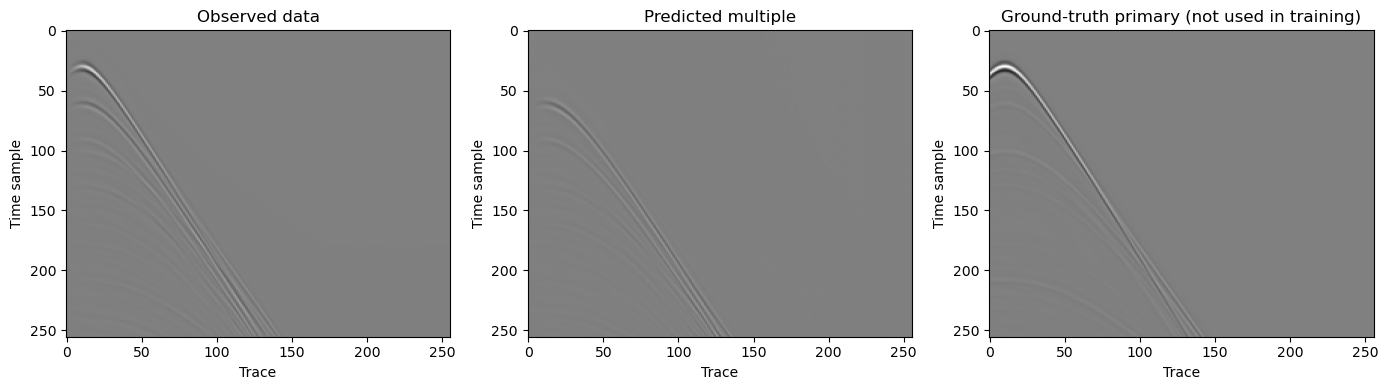

In [19]:
def show_image_triplet(obs_img, mult_img, gt_img=None, figsize=(14, 4)):
    ncols = 3 if gt_img is not None else 2
    fig, axes = plt.subplots(1, ncols, figsize=figsize)

    vmax = max(np.max(np.abs(obs_img)), np.max(np.abs(mult_img)), 1e-6)
    if gt_img is not None:
        vmax = max(vmax, np.max(np.abs(gt_img)))

    axes[0].imshow(obs_img, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
    axes[0].set_title("Observed data")
    axes[0].set_xlabel("Trace")
    axes[0].set_ylabel("Time sample")

    axes[1].imshow(mult_img, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
    axes[1].set_title("Predicted multiple")
    axes[1].set_xlabel("Trace")
    axes[1].set_ylabel("Time sample")

    if gt_img is not None:
        axes[2].imshow(gt_img, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
        axes[2].set_title("Ground-truth primary (not used in training)")
        axes[2].set_xlabel("Trace")
        axes[2].set_ylabel("Time sample")

    plt.tight_layout()
    plt.show()

show_image_triplet(obs_norm, multiple_norm, gt_primary_norm)

## 7. Patch both observed data and predicted multiple with `pyseistr`

In [20]:
Xdata = patch2d(obs_norm, l1=l1, l2=l2, s1=s1, s2=s2)
Xmultiple = patch2d(multiple_norm, l1=l1, l2=l2, s1=s1, s2=s2)

print("Raw Xdata shape     :", Xdata.shape)
print("Raw Xmultiple shape :", Xmultiple.shape)

Raw Xdata shape     : (3249, 1024)
Raw Xmultiple shape : (3249, 1024)


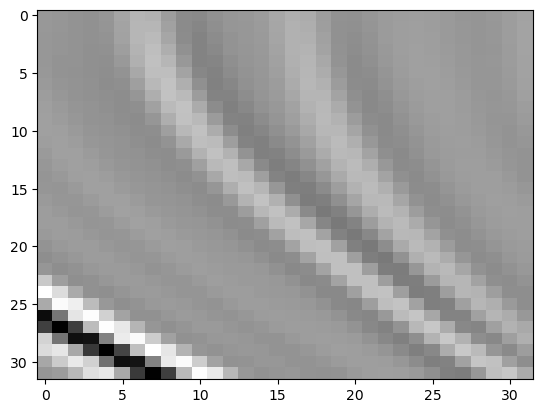

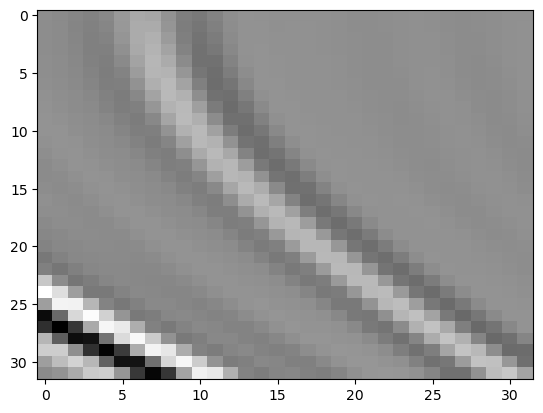

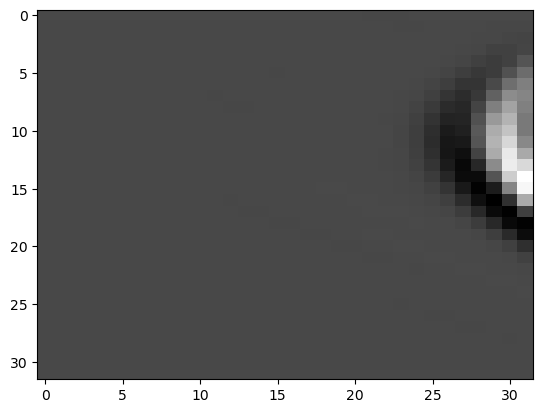

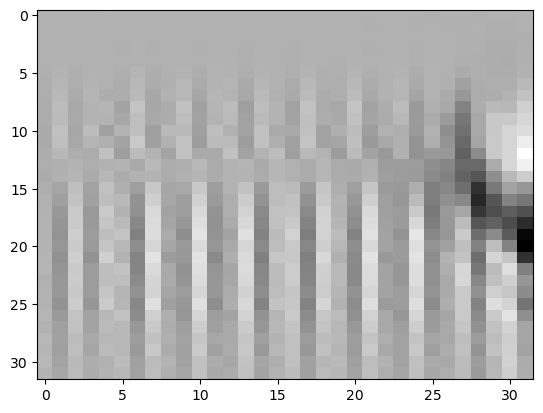

In [52]:
# quickly check a few patch samples
ids=1200
plt.imshow(Xdata[ids,:].reshape(32,32), cmap="gray", aspect="auto");plt.show()
plt.imshow(Xmultiple[ids,:].reshape(32,32), cmap="gray", aspect="auto");plt.show()
ids=0
plt.imshow(Xdata[ids,:].reshape(32,32), cmap="gray", aspect="auto");plt.show()
plt.imshow(Xmultiple[ids,:].reshape(32,32), cmap="gray", aspect="auto");plt.show()

### Standardize the patch array to `(n_patch, l1, l2)`

In [30]:
def standardize_patch_array(X, l1, l2):
    X = np.asarray(X)

    if X.ndim == 2 and X.shape[1] == l1 * l2:
        return X.reshape(X.shape[0], l1, l2, order='F')

    if X.ndim == 3:
        if X.shape[1] == l1 and X.shape[2] == l2:
            return X
        if X.shape[0] == l1 and X.shape[1] == l2:
            return np.transpose(X, (2, 0, 1))
        if X.shape[0] == l1 and X.shape[2] == l2:
            return np.transpose(X, (1, 0, 2))

    raise ValueError(f"Unsupported patch array shape: {X.shape}")

Xdata_std = standardize_patch_array(Xdata, l1=l1, l2=l2).astype(np.float32)
Xmultiple_std = standardize_patch_array(Xmultiple, l1=l1, l2=l2).astype(np.float32)

print("Standardized Xdata shape     :", Xdata_std.shape)
print("Standardized Xmultiple shape :", Xmultiple_std.shape)

Standardized Xdata shape     : (3249, 32, 32)
Standardized Xmultiple shape : (3249, 32, 32)


## 8. Visualize representative patches

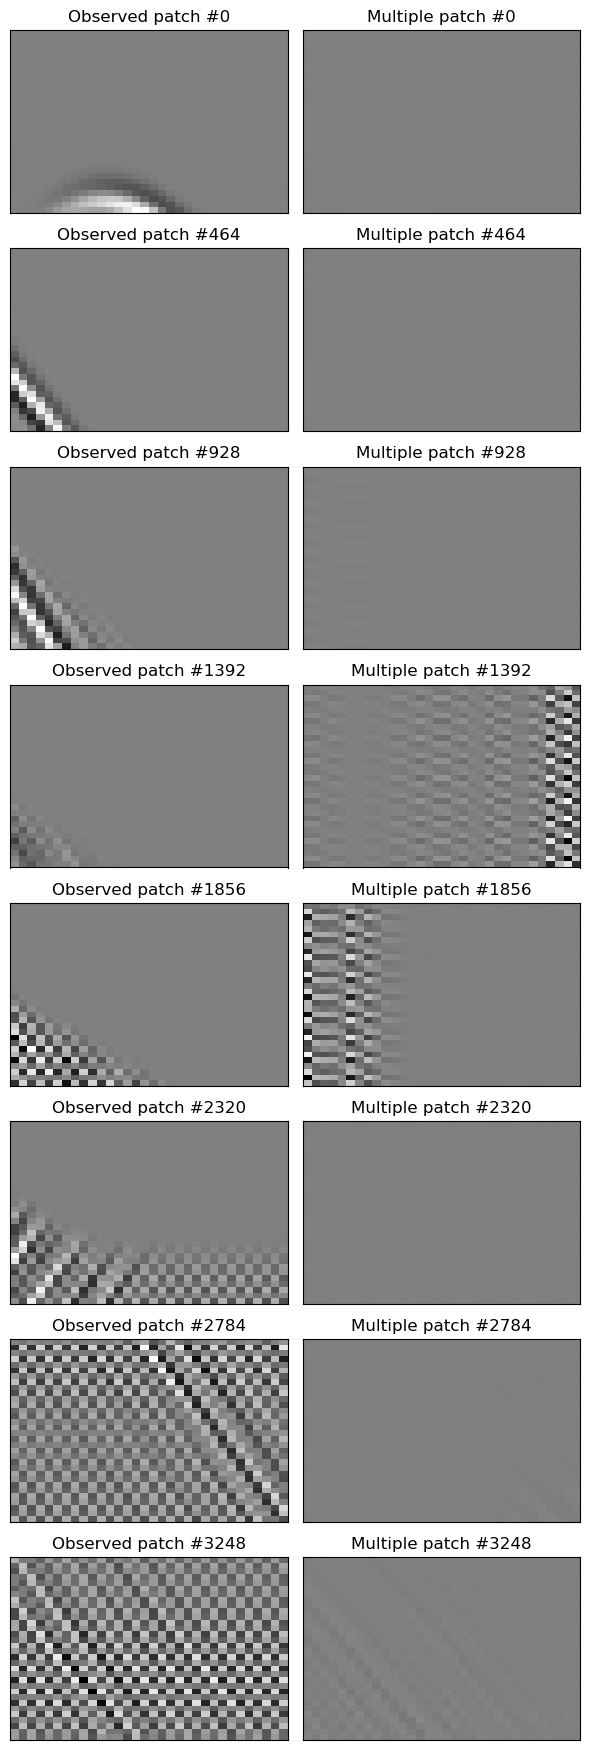

In [31]:
def show_patch_examples(Xd, Xm, num_examples=8):
    idxs = np.linspace(0, len(Xd) - 1, num_examples, dtype=int)
    fig, axes = plt.subplots(num_examples, 2, figsize=(6, 2.2 * num_examples))

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(idxs):
        dpatch = Xd[idx]
        mpatch = Xm[idx]
        vmax = max(np.max(np.abs(dpatch)), np.max(np.abs(mpatch)), 1e-6)

        axes[row, 0].imshow(dpatch, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
        axes[row, 0].set_title(f"Observed patch #{idx}")
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

        axes[row, 1].imshow(mpatch, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
        axes[row, 1].set_title(f"Multiple patch #{idx}")
        axes[row, 1].set_xticks([])
        axes[row, 1].set_yticks([])

    plt.tight_layout()
    plt.show()

show_patch_examples(Xdata_std, Xmultiple_std, num_examples=8)

## 9. Build a patch dataset

In [32]:
class PatchDataset(Dataset):
    def __init__(self, x_multiple: np.ndarray, x_data: np.ndarray):
        assert x_multiple.shape == x_data.shape
        self.xm = torch.from_numpy(x_multiple[:, None, :, :]).float()
        self.xd = torch.from_numpy(x_data[:, None, :, :]).float()

    def __len__(self):
        return self.xm.shape[0]

    def __getitem__(self, idx):
        return self.xm[idx], self.xd[idx]

patch_dataset = PatchDataset(Xmultiple_std, Xdata_std)
patch_loader = DataLoader(
    patch_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

print("Number of patches:", len(patch_dataset))
print("One batch input shape:", next(iter(patch_loader))[0].shape)

Number of patches: 3249
One batch input shape: torch.Size([64, 1, 32, 32])


/Users/chenyk/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


## 10. Define a lightweight patch-domain U-Net

In [33]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [diff_x // 2, diff_x - diff_x // 2,
             diff_y // 2, diff_y - diff_y // 2]
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class PatchUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_ch=16):
        super().__init__()
        self.inc = DoubleConv(in_channels, base_ch)
        self.down1 = Down(base_ch, base_ch * 2)
        self.down2 = Down(base_ch * 2, base_ch * 4)
        self.down3 = Down(base_ch * 4, base_ch * 8)

        self.up1 = Up(base_ch * 8 + base_ch * 4, base_ch * 4)
        self.up2 = Up(base_ch * 4 + base_ch * 2, base_ch * 2)
        self.up3 = Up(base_ch * 2 + base_ch, base_ch)

        self.outc = OutConv(base_ch, out_channels)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)
        return self.outc(x)

## 11. Unsupervised loss

We interpret the network output as the matched multiple patch:

$\widehat{X}_m = f_\theta(X_m)$

and define the primary patch estimate by subtraction:

$\widehat{X}_p = X_d - \widehat{X}_m$

A practical loss is:

$\mathcal{L}
= \lambda_{\mathrm{recon}} \| \widehat{X}_m - X_d \|_1
+ \lambda_{\mathrm{smooth}} \, TV(\widehat{X}_m)
+ \lambda_{\mathrm{primary}} \, TV(\widehat{X}_p)$

In [34]:
def total_variation(x):
    tv_h = torch.mean(torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]))
    tv_w = torch.mean(torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]))
    return tv_h + tv_w


class UnsupervisedMatchingLoss(nn.Module):
    def __init__(self, lambda_recon=1.0, lambda_smooth=1e-4, lambda_primary=1e-4):
        super().__init__()
        self.lambda_recon = lambda_recon
        self.lambda_smooth = lambda_smooth
        self.lambda_primary = lambda_primary
        self.l1 = nn.L1Loss()

    def forward(self, matched_multiple, observed_patch):
        primary_est = observed_patch - matched_multiple

        loss_recon = self.l1(matched_multiple, observed_patch)
        loss_smooth = total_variation(matched_multiple)
        loss_primary = total_variation(primary_est)

        total = (
            self.lambda_recon * loss_recon
            + self.lambda_smooth * loss_smooth
            + self.lambda_primary * loss_primary
        )

        stats = {
            "loss_total": total.item(),
            "loss_recon": loss_recon.item(),
            "loss_smooth": loss_smooth.item(),
            "loss_primary": loss_primary.item(),
        }
        return total, stats

## 12. Initialize model and optimizer

In [35]:
model = PatchUNet(in_channels=1, out_channels=1, base_ch=16).to(device)
criterion = UnsupervisedMatchingLoss(
    lambda_recon=lambda_recon,
    lambda_smooth=lambda_smooth,
    lambda_primary=lambda_primary
)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print("Trainable parameters:", count_parameters(model))

PatchUNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): Batc

## 13. Train the patch U-Net

In [36]:
history = {
    "loss_total": [],
    "loss_recon": [],
    "loss_smooth": [],
    "loss_primary": [],
}

model.train()
for epoch in range(1, num_epochs + 1):
    running = {k: 0.0 for k in history.keys()}
    n_seen = 0

    for xm_batch, xd_batch in patch_loader:
        xm_batch = xm_batch.to(device)
        xd_batch = xd_batch.to(device)

        optimizer.zero_grad()
        matched_multiple = model(xm_batch)
        loss, stats = criterion(matched_multiple, xd_batch)
        loss.backward()
        optimizer.step()

        bs = xm_batch.size(0)
        n_seen += bs
        for k in running:
            running[k] += stats[k] * bs

    for k in history:
        history[k].append(running[k] / n_seen)

    if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
        print(
            f"Epoch [{epoch:03d}/{num_epochs:03d}] | "
            f"Total: {history['loss_total'][-1]:.6f} | "
            f"Recon: {history['loss_recon'][-1]:.6f} | "
            f"TV(m): {history['loss_smooth'][-1]:.6f} | "
            f"TV(p): {history['loss_primary'][-1]:.6f}"
        )

/Users/chenyk/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch [001/080] | Total: 0.035339 | Recon: 0.035331 | TV(m): 0.037650 | TV(p): 0.044262
Epoch [010/080] | Total: 0.012065 | Recon: 0.012063 | TV(m): 0.012301 | TV(p): 0.014534
Epoch [020/080] | Total: 0.009641 | Recon: 0.009638 | TV(m): 0.012707 | TV(p): 0.013902
Epoch [030/080] | Total: 0.008599 | Recon: 0.008596 | TV(m): 0.012938 | TV(p): 0.013302
Epoch [040/080] | Total: 0.006631 | Recon: 0.006628 | TV(m): 0.013240 | TV(p): 0.012708
Epoch [050/080] | Total: 0.006331 | Recon: 0.006329 | TV(m): 0.013573 | TV(p): 0.012341
Epoch [060/080] | Total: 0.006380 | Recon: 0.006378 | TV(m): 0.013643 | TV(p): 0.012385
Epoch [070/080] | Total: 0.006014 | Recon: 0.006011 | TV(m): 0.014194 | TV(p): 0.011741
Epoch [080/080] | Total: 0.005514 | Recon: 0.005511 | TV(m): 0.014836 | TV(p): 0.011053


## 14. Plot training curves

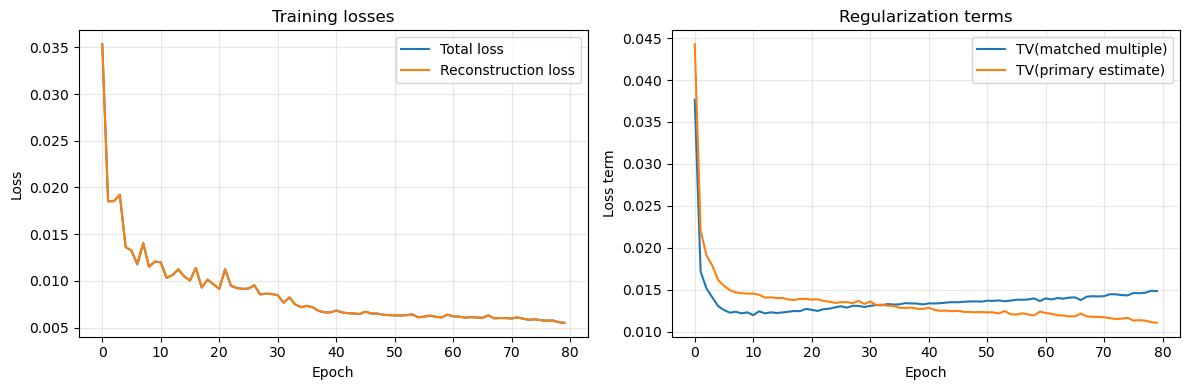

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["loss_total"], label="Total loss")
axes[0].plot(history["loss_recon"], label="Reconstruction loss")
axes[0].set_title("Training losses")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history["loss_smooth"], label="TV(matched multiple)")
axes[1].plot(history["loss_primary"], label="TV(primary estimate)")
axes[1].set_title("Regularization terms")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss term")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 15. Infer matched multiple patches and primary patches

In [38]:
model.eval()

with torch.no_grad():
    xm_tensor = torch.from_numpy(Xmultiple_std[:, None, :, :]).float().to(device)
    xd_tensor = torch.from_numpy(Xdata_std[:, None, :, :]).float().to(device)

    Xmultipleout_t = model(xm_tensor)
    Xprimaryout_t = xd_tensor - Xmultipleout_t

Xmultipleout = Xmultipleout_t.squeeze(1).cpu().numpy()
Xprimaryout = Xprimaryout_t.squeeze(1).cpu().numpy()

print("Matched multiple patches shape:", Xmultipleout.shape)
print("Estimated primary patches shape:", Xprimaryout.shape)

Matched multiple patches shape: (3249, 32, 32)
Estimated primary patches shape: (3249, 32, 32)


## 16. Visualize patch-domain outputs

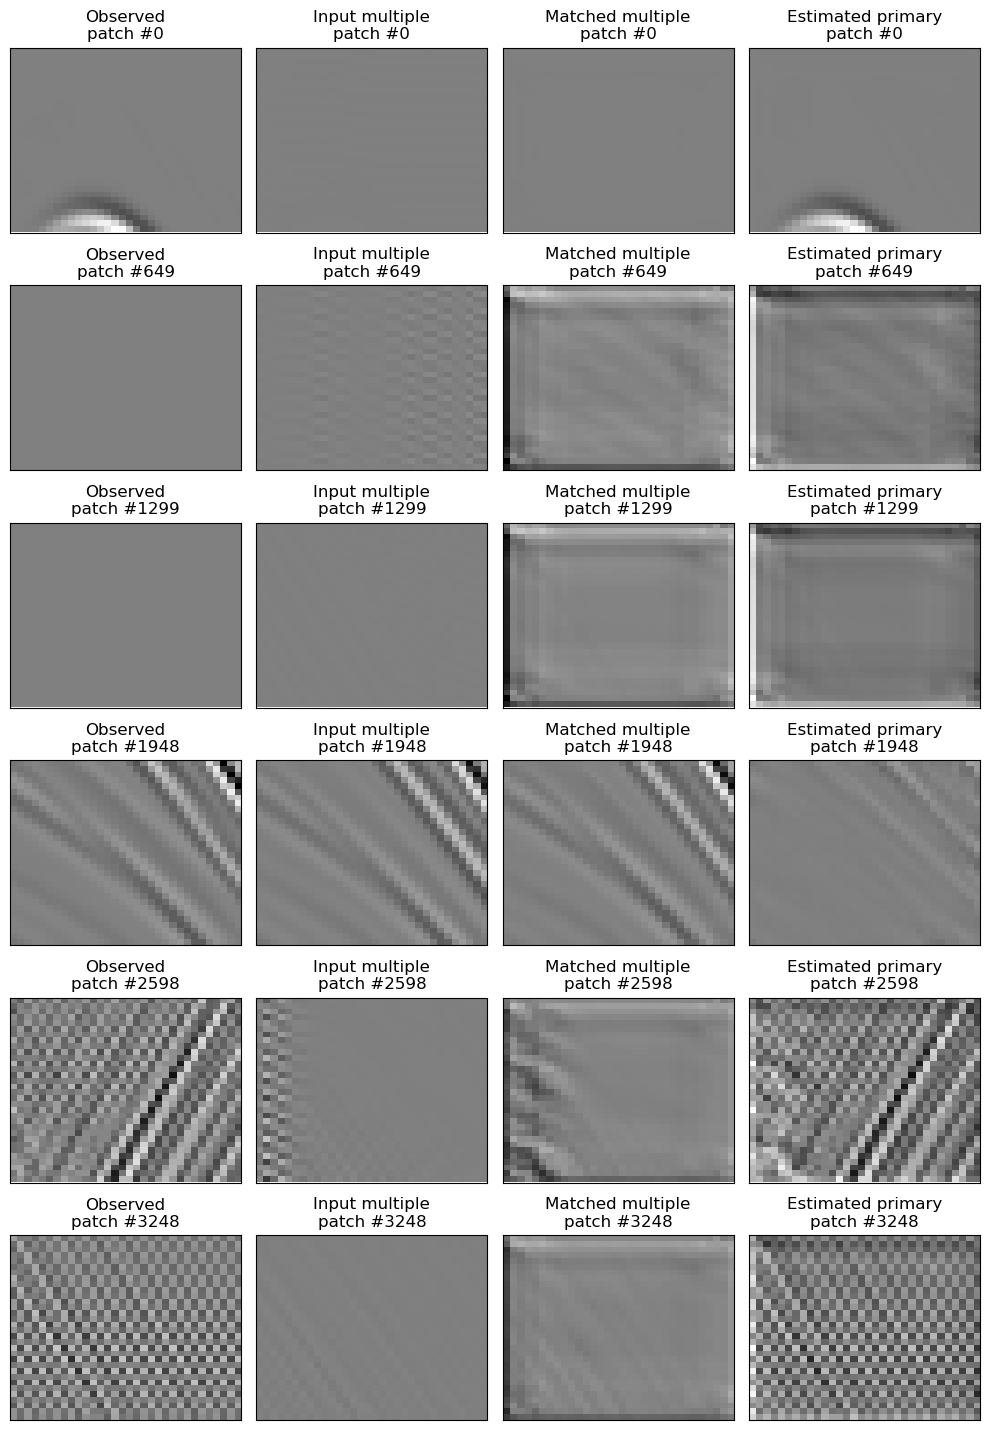

In [39]:
def show_patch_results(Xd, Xm, Xmo, Xpo, num_examples=6):
    idxs = np.linspace(0, len(Xd) - 1, num_examples, dtype=int)
    fig, axes = plt.subplots(num_examples, 4, figsize=(10, 2.4 * num_examples))

    for row, idx in enumerate(idxs):
        items = [
            (Xd[idx], "Observed"),
            (Xm[idx], "Input multiple"),
            (Xmo[idx], "Matched multiple"),
            (Xpo[idx], "Estimated primary"),
        ]
        vmax = max(max(np.max(np.abs(a)) for a, _ in items), 1e-6)

        for col, (img, title) in enumerate(items):
            ax = axes[row, col]
            ax.imshow(img, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
            ax.set_title(f"{title}\npatch #{idx}")
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()

show_patch_results(Xdata_std, Xmultiple_std, Xmultipleout, Xprimaryout, num_examples=6)

## 17. Inverse patching back to the original image domain

In [40]:
multipleout_norm = patch2d_inv(Xmultipleout, n1, n2, l1=l1, l2=l2, s1=s1, s2=s2)
primaryout_norm = patch2d_inv(Xprimaryout, n1, n2, l1=l1, l2=l2, s1=s1, s2=s2)

multipleout = multipleout_norm * scale
primaryout = primaryout_norm * scale

print("multipleout shape:", multipleout.shape)
print("primaryout shape :", primaryout.shape)

multipleout shape: (256, 256)
primaryout shape : (256, 256)


## 18. Check image-domain decomposition consistency

In [41]:
primaryout_from_subtraction = obs - multipleout
decomp_error = primaryout - primaryout_from_subtraction

print("Mean absolute decomposition error:", np.mean(np.abs(decomp_error)))
print("Max absolute decomposition error :", np.max(np.abs(decomp_error)))

Mean absolute decomposition error: 1.496001801028131e-09
Max absolute decomposition error : 2.0480823881285914e-07


## 19. Visualize final image-domain results

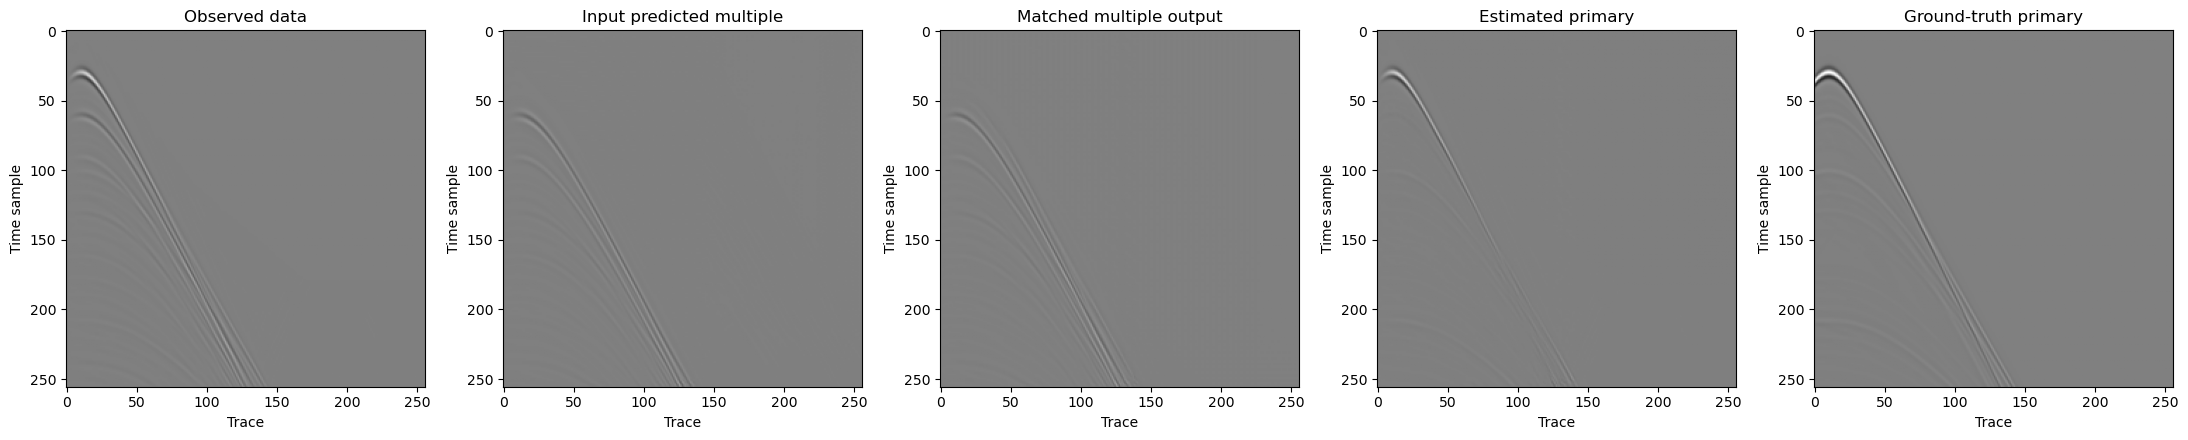

In [42]:
def show_final_results(obs, mult_in, mult_out, prim_out, gt=None):
    ncols = 5 if gt is not None else 4
    fig, axes = plt.subplots(1, ncols, figsize=(4.4 * ncols, 4.5))

    vmax = max(
        np.max(np.abs(obs)),
        np.max(np.abs(mult_in)),
        np.max(np.abs(mult_out)),
        np.max(np.abs(prim_out)),
        1e-6
    )
    if gt is not None:
        vmax = max(vmax, np.max(np.abs(gt)))

    panels = [
        (obs, "Observed data"),
        (mult_in, "Input predicted multiple"),
        (mult_out, "Matched multiple output"),
        (prim_out, "Estimated primary"),
    ]
    if gt is not None:
        panels.append((gt, "Ground-truth primary"))

    for ax, (img, title) in zip(axes, panels):
        ax.imshow(img, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel("Trace")
        ax.set_ylabel("Time sample")

    plt.tight_layout()
    plt.show()

show_final_results(obs, multiple, multipleout, primaryout, gt_primary)

## 20. Final visualizations

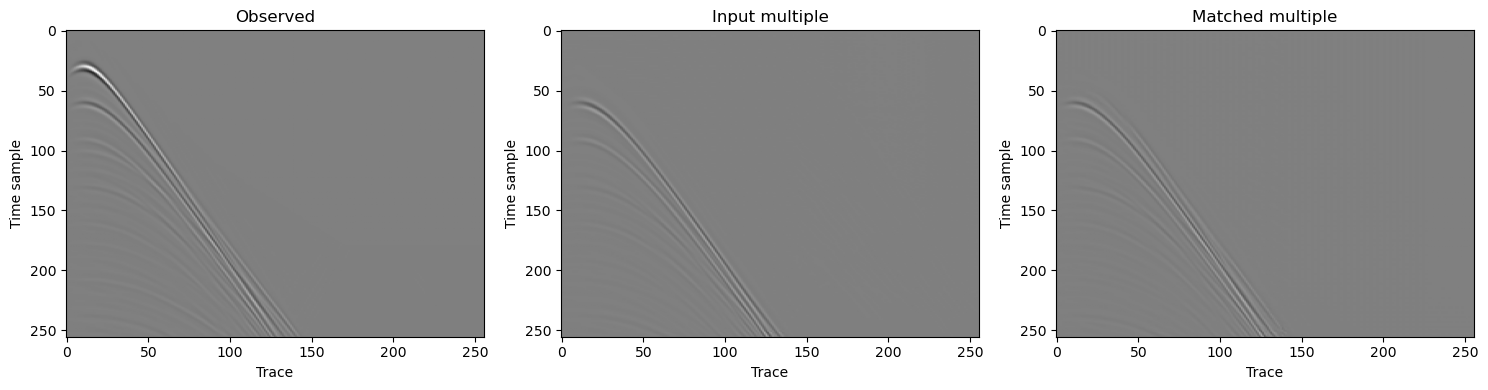

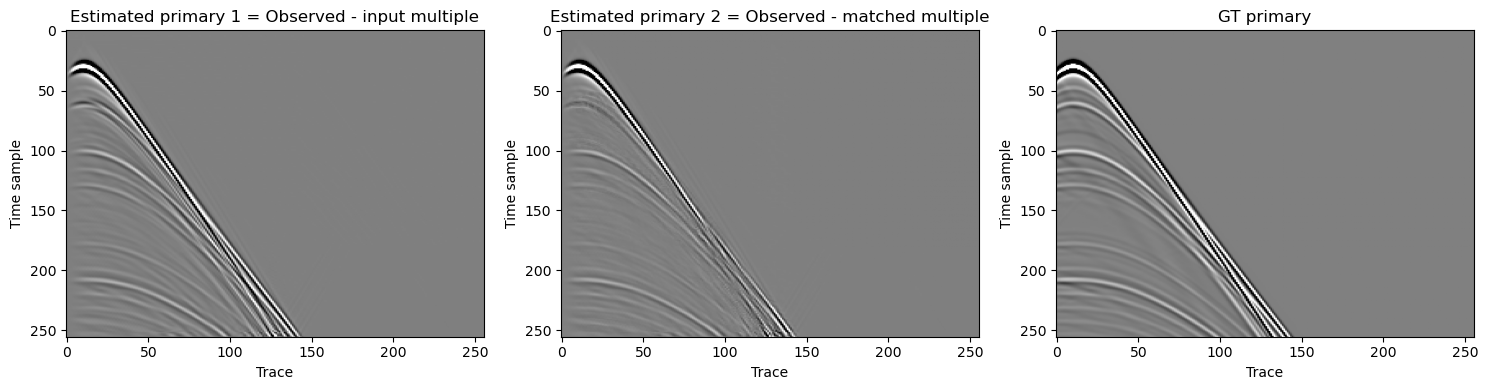

In [50]:

residual_to_gt = gt_primary - primaryout


data_minus_multin = obs - multiple
data_minus_multout = obs - multipleout

# data
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vmax = max(
    np.max(np.abs(data_minus_multin)),
    np.max(np.abs(data_minus_multout)),
    1e-6
)

axes[0].imshow(obs, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
axes[0].set_title("Observed")
axes[0].set_xlabel("Trace")
axes[0].set_ylabel("Time sample")

axes[1].imshow(multiple, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
axes[1].set_title("Input multiple")
axes[1].set_xlabel("Trace")
axes[1].set_ylabel("Time sample")

axes[2].imshow(multipleout, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
axes[2].set_title("Matched multiple")
axes[2].set_xlabel("Trace")
axes[2].set_ylabel("Time sample")

plt.tight_layout()
plt.show()

# predicted primary V.S. GT primary
fig, axes = plt.subplots(1, 3 if residual_to_gt is not None else 2, figsize=(15, 4))

vmax = vmax/10
axes[0].imshow(data_minus_multin, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
axes[0].set_title("Estimated primary 1 = Observed - input multiple")
axes[0].set_xlabel("Trace")
axes[0].set_ylabel("Time sample")

axes[1].imshow(data_minus_multout, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
axes[1].set_title("Estimated primary 2 = Observed - matched multiple")
axes[1].set_xlabel("Trace")
axes[1].set_ylabel("Time sample")

axes[2].imshow(gt_primary , cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
axes[2].set_title("GT primary")
axes[2].set_xlabel("Trace")
axes[2].set_ylabel("Time sample")

plt.tight_layout()
plt.show()

## 21. Optional quantitative evaluation against the label

In [44]:
def mae(a, b):
    return np.mean(np.abs(a - b))

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def snr_db(reference, estimate, eps=1e-12):
    num = np.sum(reference ** 2)
    den = np.sum((reference - estimate) ** 2) + eps
    return 10.0 * np.log10(num / den + eps)

if gt_primary is not None:
    print("Evaluation against ground-truth primary:")
    print("MAE  :", mae(gt_primary, primaryout))
    print("RMSE :", rmse(gt_primary, primaryout))
    print("SNR  :", snr_db(gt_primary, primaryout), "dB")

Evaluation against ground-truth primary:
MAE  : 0.042028141831937364
RMSE : 0.22845909757975089
SNR  : 4.663318095925503 dB


## 22. Save outputs

In [45]:
torch.save(model.state_dict(), os.path.join(output_dir, "patch_unet_unsupervised.pth"))

np.savez(
    os.path.join(output_dir, "unsupervised_patch_unet_outputs.npz"),
    obs=obs,
    multiple_in=multiple,
    multiple_out=multipleout,
    primary_out=primaryout,
    Xdata=Xdata_std,
    Xmultiple_in=Xmultiple_std,
    Xmultiple_out=Xmultipleout,
    Xprimary_out=Xprimaryout,
)

print("Saved model to:", os.path.join(output_dir, "patch_unet_unsupervised.pth"))
print("Saved results to:", os.path.join(output_dir, "unsupervised_patch_unet_outputs.npz"))

Saved model to: ./outputs_swan_unsupervised_patch_unet/patch_unet_unsupervised.pth
Saved results to: ./outputs_swan_unsupervised_patch_unet/unsupervised_patch_unet_outputs.npz


## 23. Conclusion

This workflow can be viewed as a **deep adaptive matching filter**:

- the input multiple model provides the physical prior
- the neural network adaptively reshapes it in the patch domain
- subtraction produces the primary estimate
- inverse patching restores the image-domain result

Compared with classical adaptive filtering:

- classical matching filters are usually linear and local
- the U-Net provides a nonlinear, data-driven, multi-scale matching operator

So this is a natural example of **physics-based unsupervised/self-supervised deep learning for adaptive multiple attenuation**.